# Downloading and Prepping data for Projecting Bat Speed 

This file
- Pulls data from statcast via pybaseball
- Aggregates monthly data over each player season
- Clean data for downstream modeling
- Visualizes exit velocity and bat speed monthly data

Much like any modeling project, we need data. This file explains my steps for pulling statcast data, transforming it, and visualizations some relationships.

## Preparing the data

In [46]:
import os
from tqdm import tqdm
from datetime import datetime
import joblib
import pandas as pd
import numpy as np
import requests

import pybaseball as pb

from sklearn.preprocessing import QuantileTransformer

from matplotlib import gridspec
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

# for reproducibility
print("pandas: "+pd.__version__)
print("numpy: "+np.__version__)
print("pybaseball: "+pb.__version__)
pb.cache.enable()

pandas: 3.0.1
numpy: 2.4.3
pybaseball: 2.2.7


Here we create some helper functions to download the data from statcast. The logic is we only need to download data from 2021 to last year once, it won't change. However, when we are in-season, we want to keep updating our local data. Therefore, when we first collect data, we set a flag called `get_prior_year=True`. This flag tells the script to pull the data from statcast, roughly 1.5 minutes per season. After it downloads the data, it saves a local version of it in a new folder called `statcast_data/statcast_{year}`. When the flag is set to false, the process will load the data from the local file location.

We also have a function to grab a player bio from the statsapi.mlb.com/api.

In [47]:
def get_statcast_data_year(year:int):
    return pb.statcast(start_dt=f'{year}-03-01', end_dt=f'{year}-10-31')

def get_year(path: str, year: int, refresh: bool):
    os.makedirs(path, exist_ok=True)
    file_path = os.path.join(path, f"statcast_{year}.csv")
    if refresh:
        print(f'pulling data for {year}')
        df = get_statcast_data_year(year)
        df.to_csv(file_path, index=False)
        return df
    else:
        print(f'loading data for {year}')
        return pd.read_csv(file_path, low_memory=False)

def get_statcast_data(get_prior_years:bool=False, path="statcast_data"):
    df_list = []
    curr_year = datetime.now().year
    curr_month = datetime.now().month
    in_season = curr_month <= 10
    for year in range(2021, curr_year):
        df_list.append(get_year(path, year, refresh=get_prior_years))

    df_list.append(get_year(path, curr_year, refresh=in_season))

    return pd.concat(df_list, ignore_index=True)

def get_player_bio(ids):
    data = []
    for pid in tqdm(ids):
        r = requests.get(f'https://statsapi.mlb.com/api/v1/people/{pid}').json()
        if r['people']:
            p = r['people'][0]
            data.append({
                'bam_id': pid,
                'full': p['nameFirstLast'],
                'first': p['useName'],
                'last': p['useLastName'],
                'bats': p['batSide']['code'],
                'position': p['primaryPosition']['abbreviation'],
                'birth_date': p['birthDate'],
                'birthCity': p.get('birthCity'),
                'birthState': p.get('birthStateProvince'),
                'birthCountry': p['birthCountry']
            })
    d = pd.DataFrame(data)
    return d

In [48]:
# Now pull data. We flipped to False.
data = get_statcast_data(get_prior_years=False)

loading data for 2021
loading data for 2022
loading data for 2023
loading data for 2024
loading data for 2025
pulling data for 2026
This is a large query, it may take a moment to complete
Skipping offseason dates


100%|██████████| 231/231 [01:28<00:00,  2.61it/s]


In [49]:
# After downloading and loading the data, clean it up

# filter to regular season
data = data.loc[data['game_type'].isin(['R'])].reset_index(drop=True)

# make a month name variable
month_map = {
    3: 'Mar/Apr', 4: 'Mar/Apr',
    5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug',
    9: 'Sep/Oct', 10: 'Sep/Oct',
}
data['game_date'] = pd.to_datetime(data['game_date'])
data['month_number']=data['game_date'].dt.month
data['year']=data['game_date'].dt.year
data['month_name']=data['month_number'].map(month_map)
data['month_name'] = pd.Categorical(data['month_name'], categories=['Mar/Apr','May','Jun','Jul','Aug','Sep/Oct'], ordered=True)
data = data.sort_values(['batter','year','month_name'])

# assuming any bat speed below 50 is a missread/non-competitive
data['bat_speed'] = data['bat_speed'].mask(data['bat_speed'] < 50)

for c in ['launch_speed','release_speed','bat_speed']:
    data[c] = data[c].astype(float)

In [50]:
# download player bio
player_ids = pd.unique(data['batter'])
player_bio = get_player_bio(player_ids)

100%|██████████| 1589/1589 [02:44<00:00,  9.65it/s]


Since our plan is to use a player's 90th percentile Exit Velocity to help "back-impute" a player's bat speed, we aggregate each player's monthly 90th percentile exit velocity (EV90).

In [51]:
pop = data.groupby(['batter','month_name','year']).agg(
        obs = ('pitch_type','count')
    ).reset_index()

# filter to only balls in play for exit velocity data
evd = data.loc[data['description']=='hit_into_play'].reset_index(drop=True)
# filter out bunts
evd['des'] = evd['des'].str.lower()
evd = evd.loc[~evd['des'].str.contains('bunt', na=False)].reset_index(drop=True)
# filter on exit velocity exists
evd = evd.loc[~evd['launch_speed'].isna()].reset_index(drop=True)
# filter out ev above 122.9
evd = evd.loc[evd['launch_speed']<123].reset_index(drop=True)

# calc 90th percentile exit velo
top90 = evd.groupby([
    'batter','month_name','year'
    ]).agg(
        ev90=('launch_speed', lambda x: np.percentile(x, 90)),
        bips=('launch_speed', 'count')
    ).reset_index()

In [52]:
top90['ev90'].describe(percentiles=[.005, .01, .05, .1, .25, .5, .75, .95])

count    15831.000000
mean       101.970951
std          6.315746
min         25.500000
0.5%        69.100000
1%          74.942000
5%          91.845000
10%         96.500000
25%        100.370000
50%        103.040000
75%        105.395000
95%        108.535000
max        117.200000
Name: ev90, dtype: float64

With Exit Velocity being a somewhat noisy estimate, we see some month observations with outlier instances. Even if we were to use these outliers, the estimates for an imputed bat speed would be very poor. Therefore, we remove instances where the EV90 is below 65mph.

<Axes: >

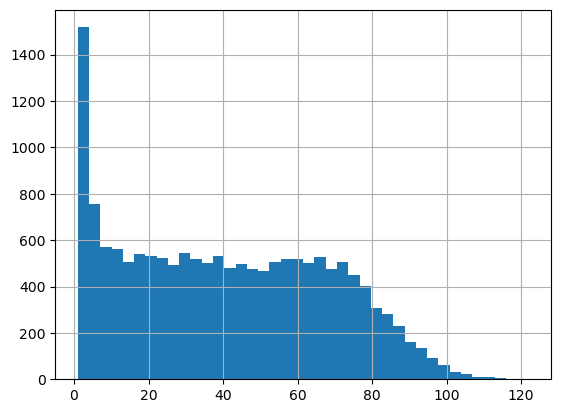

In [53]:
# remove observations where ev90<65
top90['bips'] = np.where(top90['ev90']<65, np.nan, top90['bips'])
top90['ev90'] = np.where(top90['ev90']<65, np.nan, top90['ev90'])

# plot a histogram of balls in play (BIPs)
top90['bips'].hist(bins=40)

With the histogram, we see there are many month observations with fewer than 5 bips. In these months, a player's observed EV90 is not a reflection of their true talent. Something we will have to control for when we impute bat speed.

Next, I thought we could use Alan Nathan's formula to help impute bat speed at some point. His [formula](https://community.fangraphs.com/reverse-engineering-swing-mechanics-from-statcast-data/), requires us to calculate the average pitch velocity on batted balls hit above a player's 90th Percentile, approximately. I would encourage the reader to review the article to learn about the formula. I am making some assumptions here for ease.

In [54]:
# conditional on 90th percentile ev, compute avg pitch velo faced
top = evd.merge(top90, how='left', on=['batter','month_name','year'])
top = top.loc[top['launch_speed'] >= top['ev90']].reset_index(drop=True)
top = top.groupby(['batter','month_name','year']).agg(
        avg_pitch_velocity=('release_speed', 'mean'),
        bips_hard=('launch_speed', 'count')
).reset_index()

top90 = top90.merge(top, on=['batter','month_name','year'], how='left')
pop = pop.merge(top90, on=['batter','month_name','year'], how='left')

Before we continue, let's peak at our data to confirm everything is in proper order. We should have a batter column with the ID of the player, month_name, year, and then some batted ball data

In [55]:
pop.head()

,batter,month_name,year,obs,ev90,bips,avg_pitch_velocity,bips_hard
0,405395,Mar/Apr,2021,286,106.16,63.0,92.042857,7.0
1,405395,Mar/Apr,2022,115,104.63,24.0,85.033333,3.0
2,405395,May,2021,222,108.40,41.0,91.520000,5.0
3,405395,May,2022,286,104.10,41.0,86.940000,5.0
4,405395,Jun,2021,202,103.90,41.0,84.060000,5.0


In [56]:
# Now we compile Bat Speed data and merge onto the exit velocity dataframe
batspeed_data = data.loc[~data['bat_speed'].isna()].reset_index(drop=True)
bsd = batspeed_data.groupby([
    'batter','month_name','year'
    ]).agg(
        bat_speed =('bat_speed', 'mean'),
        bat_speed_sd =('bat_speed', 'std'),
        bat_speed_50 =('bat_speed', lambda x: np.percentile(x, 50)),
        swings=('bat_speed', 'count')
    ).reset_index()
pop = pop.merge(bsd, on=['batter','month_name','year'], how='left')

# merging the bio data onto the count data
df = pop.merge(player_bio, left_on=['batter'], right_on=['bam_id'], how='left')
df.tail()

,batter,month_name,year,obs,ev90,bips,avg_pitch_velocity,bips_hard,bat_speed,bat_speed_sd,...,bam_id,full,first,last,bats,position,birth_date,birthCity,birthState,birthCountry
16273,810938,Jun,2025,302,104.50,46.0,89.500000,6.0,69.335075,5.006541,...,810938,Ben Williamson,Ben,Williamson,R,2B,2000-11-05,Fairfax,VA,USA
16274,810938,Jul,2025,315,102.00,61.0,92.842857,7.0,67.998496,5.346565,...,810938,Ben Williamson,Ben,Williamson,R,2B,2000-11-05,Fairfax,VA,USA
16275,814439,May,2026,68,101.70,13.0,91.200000,2.0,73.650000,4.502946,...,814439,Ryan Waldschmidt,Ryan,Waldschmidt,R,CF,2002-10-07,Sarasota,FL,USA
16276,823550,May,2026,70,100.96,9.0,94.500000,1.0,70.470370,3.780295,...,823550,Sung-Mun Song,Sung-Mun,Song,L,2B,1996-08-29,Seoul,NaN,Republic of Korea
16277,829272,Aug,2025,3,NaN,NaN,NaN,NaN,NaN,NaN,...,829272,Shinnosuke Ogasawara,Shinnosuke,Ogasawara,L,P,1997-10-08,Fujisawa,NaN,Japan


In [57]:
# More transforming and cleaning....

# formula to compute bat speed
df['imputed_bat_speed'] = (df['ev90'] - 0.21*df['avg_pitch_velocity']*(1-.084))/(1+.21)

# remove pitchers and encode a few different postitional groupings
df = df.loc[df['position']!='P'].reset_index(drop=True)
df['position'] = np.where(df['position']=='TWP','DH', df['position'])
df['position_group'] = np.where(df['position'].isin(['DH','1B','3B','LF','RF','OF']),'Power','Defense')
df['position_hybrid'] = np.where(df['position'].isin(['LF','RF','OF']),'COF',df['position'])
df['position_hybrid'] = np.where(df['position'].isin(['1B','3B']),'CINF',df['position_hybrid'])
df['position_hybrid'] = np.where(df['position'].isin(['SS','2B','CF']),'UTM',df['position_hybrid'])

# changing columns to floats
for c in ['ev90', 'bips','avg_pitch_velocity', 'bips_hard', 'bat_speed', 'bat_speed_sd','bat_speed_50','swings','age', 'imputed_bat_speed']:
    try:
        df[c] = df[c].astype(float)
    except KeyError:
        continue

# https://www.baseballprospectus.com/news/article/28956/baseball-therapy-the-one-about-exit-velocity/#:~:text=At%2040%2Dsomething%20balls%20in,to%20come%20in%20the%20season.
MIN_BIPS = 40
MIN_SWINGS = 10
# define approx thresholds based on prior studies
df['is_bip_threshold'] = np.where((df['bips']>=MIN_BIPS), 1, 0) # meets threshold
df['is_swing_threshold'] = np.where((df['swings']>=MIN_SWINGS), 1, 0) # meets threshold
df['is_ev90_na'] = np.where(df['ev90'].isna(), 1, 0) # have no ev90
df['is_bat_speed_na'] = np.where(df['bat_speed'].isna(), 1, 0) # have no bat speed
# remove the instances with no bips and no bat speed, we cant learn from players that never played
df = df.loc[~((df['is_bat_speed_na']==1) & (df['is_ev90_na']==1))].reset_index(drop=True)

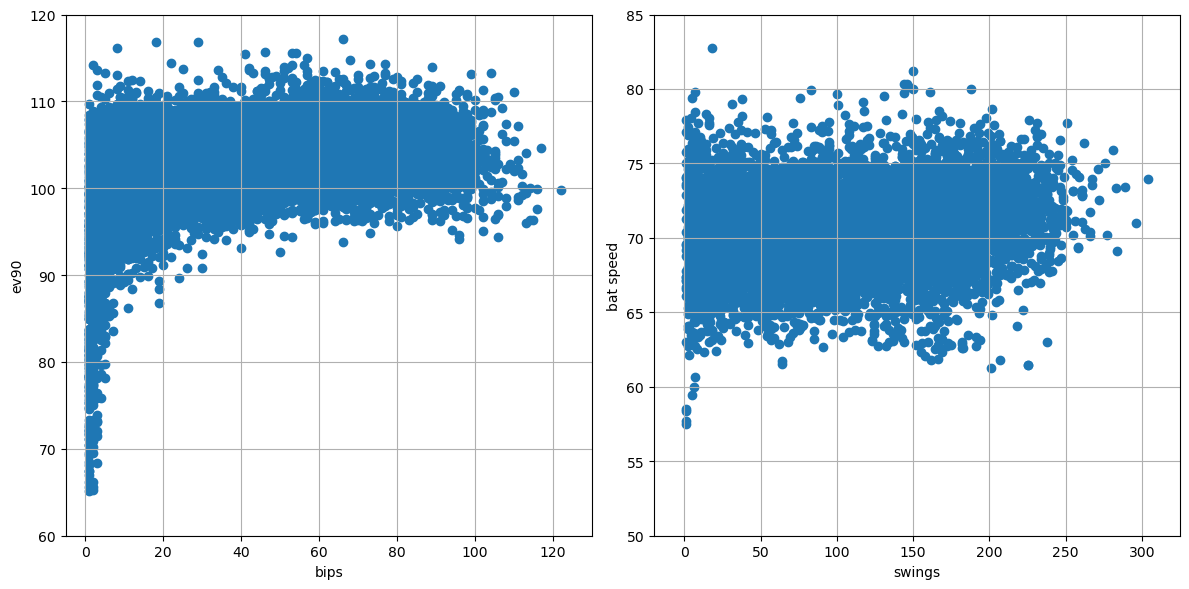

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

ax[0].scatter(df['bips'], df['ev90'])
ax[0].set_xlabel('bips')
ax[0].set_ylabel('ev90')
ax[0].set_xlim(-5, 130)
ax[0].set_ylim(60, 120)
ax[0].grid()

ax[1].scatter(df['swings'], df['bat_speed'])
ax[1].set_xlabel('swings')
ax[1].set_ylabel('bat speed')
ax[1].set_xlim(-20, 325)
ax[1].set_ylim(50, 85)
ax[1].grid()
plt.tight_layout()

Here we illustrate how noisy EV90 is relative to Bat Speed. A metric can be noisy such that it changes due to sample size. So with the exit velocity data, we see that small samples have a larger variance in the observed monthly data. Bat Speed is less noisy, it takes about 10 swings to stabilize and most player's, even a bench player, should get 10 swings in a month.

In [59]:
# Here we define cases for each month observation.
# I'm not sure if I will use this, but it can't hurt.

# complete cases with a bat speed and ev90
df['obs_type'] = np.where((df['is_bat_speed_na']==0)&(df['is_ev90_na']==0),'complete','miss')
# cases with only bat speed
df['obs_type'] = np.where((df['is_bat_speed_na']==0)&(df['is_ev90_na']==1),'batspeed_only', df['obs_type'])
# cases with only ev90
df['obs_type'] = np.where((df['is_bat_speed_na']==1)&(df['is_ev90_na']==0),'ev_only', df['obs_type'])

df['n_type'] = np.where((df['is_bip_threshold']==1)&(df['is_swing_threshold']==1),'complete','incomplete')
df['n_type'] = np.where((df['is_bip_threshold']==0)&(df['is_swing_threshold']==1),'batspeed_only', df['n_type'])
df['n_type'] = np.where((df['is_bip_threshold']==1)&(df['is_swing_threshold']==0),'ev_only', df['n_type'])

In [60]:
# From the bio data, we have birth country. Here we clean it up and roll up some additional categories.
df['birthCountry'] = np.where(df['birthCountry'].isin(['DOM']),'Dominican Republic', df['birthCountry'])
df['birthCountry'] = np.where(df['birthCountry'].isin(['VEN']),'Venezuela', df['birthCountry'])
df['region'] = np.where(df['birthCountry'].isin(['Cuba','Mexico','Panama','Colombia','Curacao','Aruba','Honduras','Bahamas','Brazil']),'Latin America', df['birthCountry'])
df['region'] = np.where(df['birthCountry'].isin(['Republic of Korea','Japan','Australia','Taiwan']),'Pacific', df['region'])
df['region'] = np.where(df['birthCountry'].isin(['Netherlands','Germany','Italy']),'Europe', df['region'])

# https://en.wikipedia.org/wiki/List_of_regions_of_the_United_States
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['CT','ME','MA','NH','RI','VT'])), 'New England', df['birthState'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['NY','NJ','PA'])), 'Mid-Atlantic', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['IL','IN','MI','OH','WI'])), 'East North Central', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['IA','KS','MN','MO','NE','ND','SD'])), 'West North Central', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['GA','NC','SC'])), 'South Atlantic', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['VA','WV'])), 'Virginias', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['DE','DC','MD'])), 'South Mid-Atlantic', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['AL','KY','MS','TN'])), 'East South Central', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['AR','LA','OK','TX'])), 'West South Central', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['AZ','CO','ID','MT','NV','NM','UT','WY'])), 'Mountain', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['AK','HI','OR','WA'])), 'Pacific North West', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['FL'])), 'Florida', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['CA'])), 'California', df['division'])

conditions = [
    (df['region']=='Dominican Republic')&(df['birthCity'].str.contains('Santo Domingo', na=False)),
    (df['region']=='Dominican Republic')&(df['birthCity']=='Santiago'),
    (df['region']=='Venezuela')&(df['birthCity'].str.contains('Caracas', na=False)),
    (df['region']=='Venezuela')&(df['birthCity'].str.contains('Maracaibo', na=False)),
    (df['region']=='Venezuela')&(df['birthCity'].str.contains('Valencia', na=False)),
    (df['region']=='Venezuela')&(df['birthCity'].str.contains('Maracay', na=False)),
    (df['region']=='Venezuela')&(df['birthCity'].str.contains('Barquisimeto', na=False)),
]
choices = [
    'Santo Domingo, DR', 
    'Santiago, DR',
    'Caracas, VE',
    'Maracaibo, VE',
    'Valencia, VE',
    'Maracay, VE',
    'Barquisimeto, VE'
]
df['country'] = np.select(conditions, choices, default=df['region'])
df['country'] = np.where(df['region']=='USA', df['division']+', USA', df['country'])
df['country2'] = np.where(df['region']=='USA', df['division']+', USA', df['region'])


In [61]:
# center, standardize, and quantize our data
df['ev90_center'] = df['ev90'] - df['ev90'].mean()
df['bat_speed_center'] = df['bat_speed'] - df['bat_speed'].mean()
df['imputed_bat_speed_center'] = df['imputed_bat_speed'] - df['imputed_bat_speed'].mean()

df['ev90_z'] =  df['ev90_center']/ df['ev90'].std()
df['bat_speed_z'] =  df['bat_speed_center']/ df['bat_speed'].std()
df['imputed_bat_speed_z'] =  df['imputed_bat_speed_center']/ df['imputed_bat_speed_center'].std()

df = df.reset_index(drop=True)
qt = QuantileTransformer(random_state=0, output_distribution="normal")
qt_values = pd.DataFrame(qt.fit_transform(df[['ev90','bat_speed','imputed_bat_speed']]), columns=['ev90_qt','bat_speed_qt','imputed_bat_speed_qt'])
df = pd.concat([df, qt_values], axis=1)

joblib.dump(qt, 'quantile_scaler.pkl')

['quantile_scaler.pkl']

Now that we have cleaned and transformed our data, we string it together. For each player, we create a grid of values to merge the data onto. Rather than having the grid start in 2021 for everyone, we start it at a player's "debut year". We put debut in quotes because players clearly debuted prior to 2021, but our dataset only goes back as far. The objective here is to avoid creating a bunch of empty rows for players like Konnor Griffin we debuted in 2026.

In [62]:
debut = df.dropna(subset=['ev90']).groupby('bam_id')['year'].min().reset_index().rename(columns={'year':'debut_year'})

seasons = sorted(pd.unique(df['year']))
months = df['month_name'].cat.categories
year_month_index = pd.MultiIndex.from_product([seasons, months], names=['year','month_name']).to_frame(index=False).reset_index(drop=False).rename(columns={'index': 'time_index'})

grid_rows = []
for _, row in debut.iterrows():
    for season in [s for s in pd.unique(df['year']) if s >= row['debut_year']]:
        for month in pd.unique(df['month_name']):
            grid_rows.append({
                'bam_id': row['bam_id'],
                'year': season,
                'month_name': month
            })

grid = pd.DataFrame(grid_rows)
grid_shape = grid.shape[0]

grid = grid.merge(year_month_index, on=['year','month_name'], how='left')

subset_df = df[[
    'bam_id','month_name','year',
    'bips','ev90','ev90_center','ev90_z','ev90_qt',
    'imputed_bat_speed','imputed_bat_speed_center','imputed_bat_speed_z','imputed_bat_speed_qt',
    'swings','bat_speed','bat_speed_center','bat_speed_z','bat_speed_qt',
    'obs_type','n_type'
    ]]
grid = grid.merge(subset_df, on=['bam_id','month_name','year'], how='left')
assert grid.shape[0] == grid_shape

# bio data
bio_subset = df[[
    'bam_id','full','first','last','bats',
    'birth_date',
    'position','position_group','position_hybrid',
    'region','country','country2',
]].drop_duplicates(['bam_id'])
grid = grid.merge(bio_subset, on=['bam_id'], how='left')

grid['month_name'] = pd.Categorical(grid['month_name'], categories=['Mar/Apr','May','Jun','Jul','Aug','Sep/Oct'], ordered=True)
assert grid.shape[0] == grid_shape

grid.sort_values(['bam_id','year','month_name']).head(10)

,bam_id,year,month_name,time_index,bips,ev90,ev90_center,ev90_z,ev90_qt,imputed_bat_speed,...,first,last,bats,birth_date,position,position_group,position_hybrid,region,country,country2
0,405395,2021,Mar/Apr,0,63.0,106.16,3.536708,0.735407,0.869846,73.103005,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic
1,405395,2021,May,1,41.0,108.40,5.776708,1.201182,1.558482,75.037366,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic
2,405395,2021,Jun,2,41.0,103.90,1.276708,0.265473,0.191865,72.504313,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic
3,405395,2021,Jul,3,44.0,105.79,3.166708,0.658471,0.766391,73.576653,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic
4,405395,2021,Aug,4,19.0,105.56,2.936708,0.610645,0.692715,72.717284,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic
5,405395,2021,Sep/Oct,5,24.0,105.10,2.476708,0.514995,0.549616,73.187636,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic
6,405395,2022,Mar/Apr,6,24.0,104.63,2.006708,0.417266,0.408805,72.952883,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic
7,405395,2022,May,7,41.0,104.10,1.476708,0.307060,0.247134,72.211753,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic
8,405395,2022,Jun,8,29.0,105.14,2.516708,0.523313,0.561327,72.786162,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic
9,405395,2022,Jul,9,44.0,107.85,5.226708,1.086817,1.397231,74.481076,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic


In [63]:
# now we compute age for every player in a month
# going to compute age measured on the 15th of each month
month_map_num = {
    'Mar/Apr': 4, 'May': 5, 'Jun': 6, 
    'Jul': 7, 'Aug': 8, 'Sep/Oct': 9
}
def get_age(row):
    bday = pd.to_datetime(row['birth_date'])
    ref_year = int(row['year'])
    ref_month = month_map_num.get(row['month_name'])
    ref_date = pd.Timestamp(year=ref_year, month=ref_month, day=15)
    days_diff = (ref_date - bday).days
    age = days_diff/365.25
    return age

grid['age'] = grid.apply(get_age, axis=1)
grid['age_center'] = grid['age'] - grid['age'].mean()
grid['age_z'] = grid['age_center']/ grid['age'].std()

grid = grid.reset_index(drop=True)
qt_age = QuantileTransformer(random_state=0, output_distribution="normal")
qt_values = pd.DataFrame(qt_age.fit_transform(grid[['age']]), columns=['age_qt'])
grid = pd.concat([grid, qt_values], axis=1)

joblib.dump(qt_age, 'quantile_age.pkl')

['quantile_age.pkl']

In [64]:
# peak at the younger players to confirm reasonable values
grid.loc[grid['age']<20][['birth_date','full','month_name','year','age']].sort_values(['age','year','month_name'])

,birth_date,full,month_name,year,age
33294,2003-07-05,Junior Caminero,Mar/Apr,2023,19.778234
33295,2003-07-05,Junior Caminero,May,2023,19.860370
33296,2003-07-05,Junior Caminero,Jun,2023,19.945243
34422,2006-04-24,Konnor Griffin,Mar/Apr,2026,19.975359


In [65]:
grid.to_csv('data.csv',index=False)

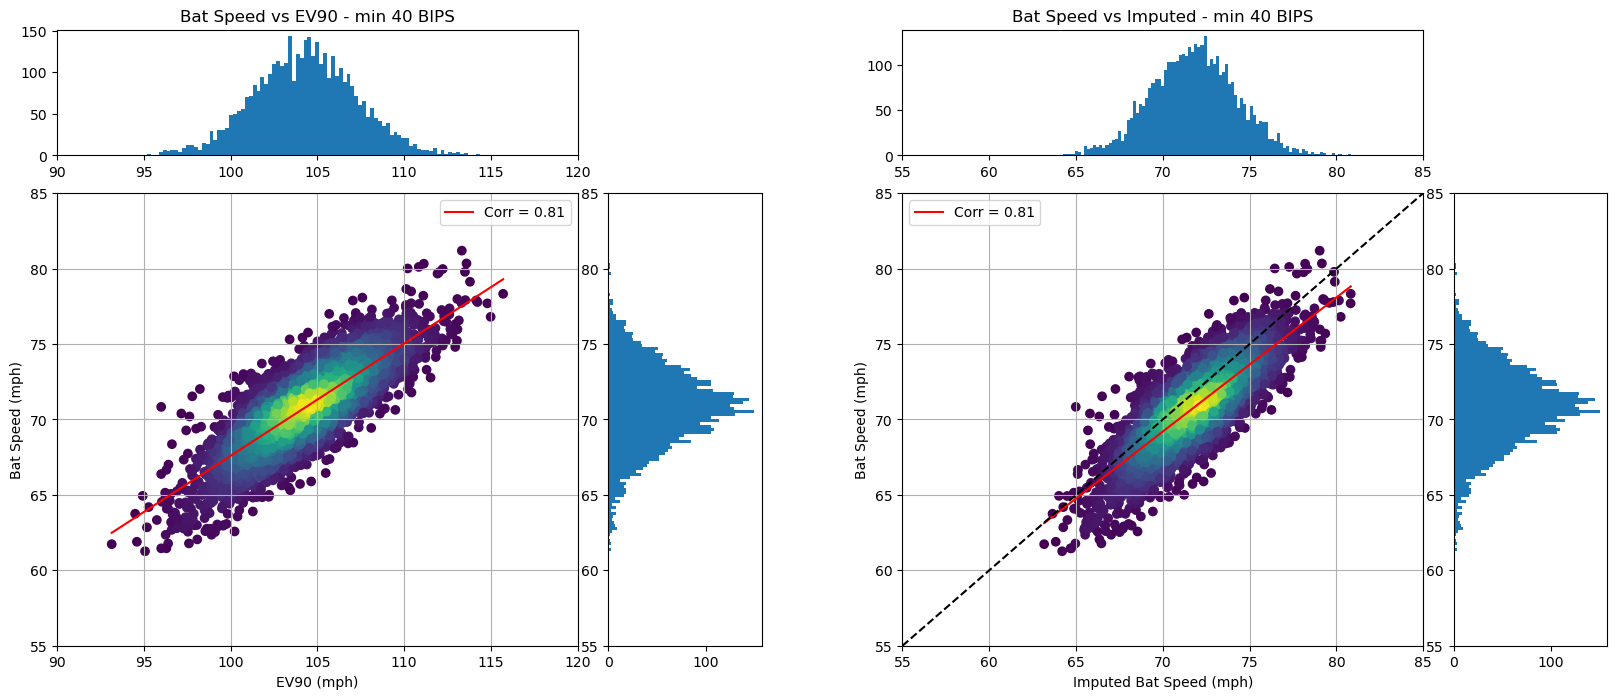

In [66]:
def draw_joint(fig, outer_cell, x, y, xlabel, ylabel, title, xlim=None, ylim=None, xticks=None, yticks=None, diag=False):
    gs = gridspec.GridSpecFromSubplotSpec(4, 4, subplot_spec=outer_cell, wspace=0.2, hspace=0.3)
    ax_joint = fig.add_subplot(gs[1:4, 0:3])
    ax_marg_x = fig.add_subplot(gs[0, 0:3])
    ax_marg_y = fig.add_subplot(gs[1:4, 3])

    xy = np.vstack([x, y])
    density = gaussian_kde(xy)(xy)

    ax_joint.scatter(x, y, c=density, cmap='viridis')
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax_joint.plot(x_line, m * x_line + b, color='red', label=f'Corr = {np.corrcoef(x,y)[0,1]:.2f}')
    ax_joint.axline((0, 0), slope=1, color='black', linestyle='--')
    ax_joint.set_xlabel(xlabel)
    ax_joint.set_xlim(xlim)
    ax_joint.set_ylim(ylim)
    ax_joint.set_xticks(xticks)
    ax_joint.set_yticks(yticks)
    ax_joint.set_ylabel(ylabel)
    ax_joint.legend()
    ax_joint.grid(True)
    ax_marg_x.hist(x, bins=100)
    ax_marg_y.hist(y, bins=100, orientation='horizontal')
    ax_marg_x.set_title(title)
    ax_marg_x.set_xticks(xticks)
    ax_marg_y.set_yticks(yticks)

fig = plt.figure(figsize=(20, 8))
outer = gridspec.GridSpec(1, 2, figure=fig)

cd1 = grid.dropna(subset=['bat_speed', 'ev90']).copy()
cd1 = cd1.loc[cd1['bips'] >= MIN_BIPS]
x1, y1 = cd1['ev90'].values.astype(float), cd1['bat_speed'].values.astype(float)
draw_joint(fig, outer[0], x1, y1, 'EV90 (mph)', 'Bat Speed (mph)', f'Bat Speed vs EV90 - min {MIN_BIPS} BIPS',
           xlim = (90,120), ylim = (55,85), xticks = np.arange(90, 121, 5), yticks=np.arange(55, 86, 5)
        )

cd2 = grid.dropna(subset=['bat_speed', 'imputed_bat_speed']).copy()
cd2 = cd2.loc[cd2['bips'] >= MIN_BIPS]
x2, y2 = cd2['imputed_bat_speed'].values.astype(float), cd2['bat_speed'].values.astype(float)
draw_joint(fig, outer[1], x2, y2, 'Imputed Bat Speed (mph)', 'Bat Speed (mph)', f'Bat Speed vs Imputed - min {MIN_BIPS} BIPS',
           xlim = (55,85), ylim = (55,85), xticks = np.arange(55, 86, 5), yticks=np.arange(55, 86, 5)
        )

To help illustrate the relationship between EV90, Imputed Bat Speed, and Observed Bat Speed, we compare their joint empirical distribution. We do filter to players that have stable exit velocities because otherwise, we would be comparing noisy estimates. Even without the Imputed Bat Speed, a player's 90th percentile Exit Velocity has a 0.81 correlation with their Bat Speed. Therefore, imputing bat speed with EV90 is likely sufficent via some modeling process.